In [1]:
import sys
sys.path.insert(0, "../../")

In [2]:
import torch
from src.models.forecasting import ForecastingTransformer

model = ForecastingTransformer()
print(model)


ForecastingTransformer(
  (input_projection): Linear(in_features=3, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_projection): Linear(in_features=64, out_features=3, bias=True)
)


/home/justmouheb/miniconda3/envs/ai/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/justmouheb/AI-dezem/anomaly-transformer/notebooks/dezem/../../src/models/forecasting.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)


In [10]:
x = torch.randn(4, 48, 3)
output = model(x)
print("Input shape: ", x.shape)
print("Output shape:", output.shape)  # should be (4, 3)


RuntimeError: Expected all tensors to be on the same device, but got mat2 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_mm)

In [11]:
import numpy as np
from torch.utils.data import Dataset, DataLoader

class ForecastingDataset(Dataset):
    def __init__(self, feats: np.ndarray, seq_len: int = 48):
        self.feats = torch.tensor(feats, dtype=torch.float32)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.feats) - self.seq_len

    def __getitem__(self, idx):
        x = self.feats[idx : idx + self.seq_len]
        y = self.feats[idx + self.seq_len]
        return x, y


In [12]:
from src.data.dezem import load_dezem_csv, compute_window_features

# load data
train_loader, val_loader, meta = load_dezem_csv(
    "/mnt/c/Users/Hidou/Downloads/Dezem 2 years.csv",
    window_size=24
)

feats = compute_window_features(meta["values_norm"], window_size=24)
split = int(len(feats) * 0.8)
train_feats = feats[:split]
val_feats = feats[split:]

train_dataset = ForecastingDataset(train_feats, seq_len=48)
val_dataset = ForecastingDataset(val_feats, seq_len=48)

print("Train samples:", len(train_dataset))
print("Val samples:  ", len(val_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

x_batch, y_batch = next(iter(train_loader))
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)


Dropping 2 duplicate timestamps (keeping first)
Filling 74 missing hourly timestamps via time interpolation
Loaded 16,704 hourly points
Range: [0.59, 1453.01]  Mean: 164.88  Std: 244.29
Windows — train: 13,340  val: 3,318  (window=24h, stride=1)
Train samples: 13296
Val samples:   3289
x_batch shape: torch.Size([32, 48, 3])
y_batch shape: torch.Size([32, 3])


In [13]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
model = ForecastingTransformer().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss()
num_epochs = 50
train_losses = []
val_losses = []
for epoch in range(num_epochs):
    #training
    model.train()
    total_train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(x_batch)
        loss = loss_fn(predictions, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    #validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(x_batch)
            loss = loss_fn(predictions, y_batch)
            total_val_loss += loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val = total_val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")


Using device: cuda


/home/justmouheb/AI-dezem/anomaly-transformer/notebooks/dezem/../../src/models/forecasting.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer = nn.TransformerEncoder(encoder_layer,num_layers=num_layers)


Epoch 01/50 | Train Loss: 0.1861 | Val Loss: 0.0936
Epoch 02/50 | Train Loss: 0.1010 | Val Loss: 0.0877
Epoch 03/50 | Train Loss: 0.0916 | Val Loss: 0.0755
Epoch 04/50 | Train Loss: 0.0874 | Val Loss: 0.0749
Epoch 05/50 | Train Loss: 0.0831 | Val Loss: 0.1161
Epoch 06/50 | Train Loss: 0.0860 | Val Loss: 0.0716
Epoch 07/50 | Train Loss: 0.0804 | Val Loss: 0.0820
Epoch 08/50 | Train Loss: 0.0781 | Val Loss: 0.0735
Epoch 09/50 | Train Loss: 0.0771 | Val Loss: 0.0747
Epoch 10/50 | Train Loss: 0.0751 | Val Loss: 0.0798
Epoch 11/50 | Train Loss: 0.0745 | Val Loss: 0.0707
Epoch 12/50 | Train Loss: 0.0732 | Val Loss: 0.0655
Epoch 13/50 | Train Loss: 0.0705 | Val Loss: 0.0781
Epoch 14/50 | Train Loss: 0.0682 | Val Loss: 0.0709
Epoch 15/50 | Train Loss: 0.0703 | Val Loss: 0.0741
Epoch 16/50 | Train Loss: 0.0656 | Val Loss: 0.0831
Epoch 17/50 | Train Loss: 0.0664 | Val Loss: 0.0677
Epoch 18/50 | Train Loss: 0.0685 | Val Loss: 0.0668
Epoch 19/50 | Train Loss: 0.0668 | Val Loss: 0.0751
Epoch 20/50 

In [16]:
optimizer.zero_grad()
predictions = model(x_batch)
loss = loss_fn(predictions, y_batch)
loss.backward()
optimizer.step()


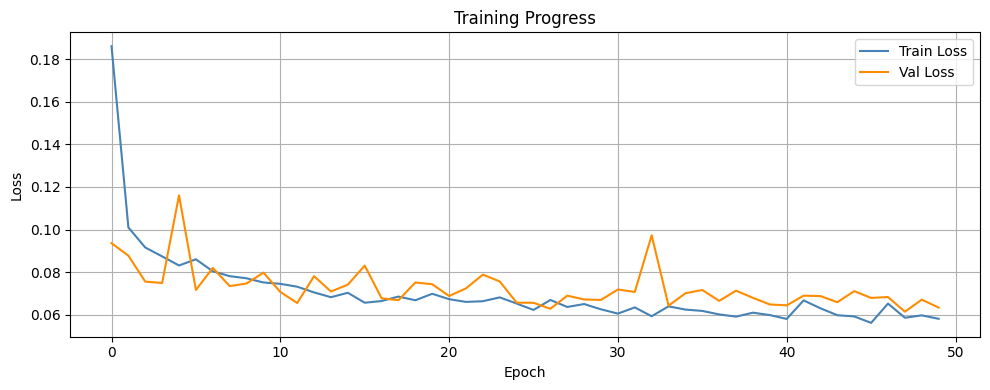

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", color="steelblue")
plt.plot(val_losses, label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Progress")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()


In [18]:
torch.save(model.state_dict(), "../../checkpoints/forecasting_dezem.pt")
print("Model saved.")


Model saved.


In [19]:
model.eval()
errors = []

with torch.no_grad():
    for i in range(len(feats) - 48):
        x = torch.tensor(feats[i:i+48], dtype=torch.float32).unsqueeze(0).to(device)
        y = torch.tensor(feats[i+48], dtype=torch.float32).to(device)
        pred = model(x).squeeze(0)
        error = torch.abs(pred - y).mean().item()
        errors.append(error)

errors = np.array(errors)
print("Errors shape:", errors.shape)
print("Mean error:", errors.mean().round(4))
print("Max error: ", errors.max().round(4))


Errors shape: (16633,)
Mean error: 0.0793
Max error:  1.5851


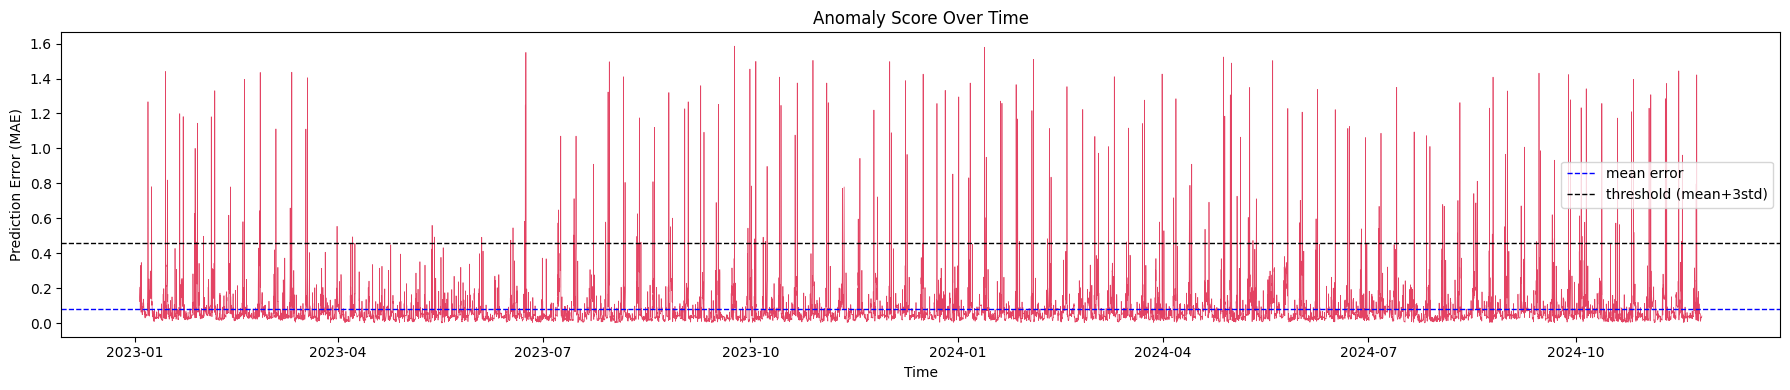

In [20]:
time_index = meta["index"][48:48+len(errors)]

plt.figure(figsize=(18, 4))
plt.plot(time_index, errors, color="crimson", linewidth=0.5, alpha=0.8)
plt.axhline(errors.mean(), color="blue", linestyle="--", linewidth=1, label="mean error")
plt.axhline(errors.mean() + 3*errors.std(), color="black", linestyle="--", linewidth=1, label="threshold (mean+3std)")
plt.title("Anomaly Score Over Time")
plt.xlabel("Time")
plt.ylabel("Prediction Error (MAE)")
plt.legend()
plt.tight_layout()
plt.savefig("anomaly_scores.png", dpi=150)
plt.show()


In [21]:
print(f"Mean error:        {errors.mean():.4f}")
print(f"Std error:         {errors.std():.4f}")
print(f"90th percentile:   {np.percentile(errors, 90):.4f}")
print(f"95th percentile:   {np.percentile(errors, 95):.4f}")
print(f"99th percentile:   {np.percentile(errors, 99):.4f}")
print(f"99.5th percentile: {np.percentile(errors, 99.5):.4f}")
print(f"Max error:         {errors.max():.4f}")


Mean error:        0.0793
Std error:         0.1257
90th percentile:   0.1505
95th percentile:   0.2214
99th percentile:   0.6048
99.5th percentile: 1.1249
Max error:         1.5851


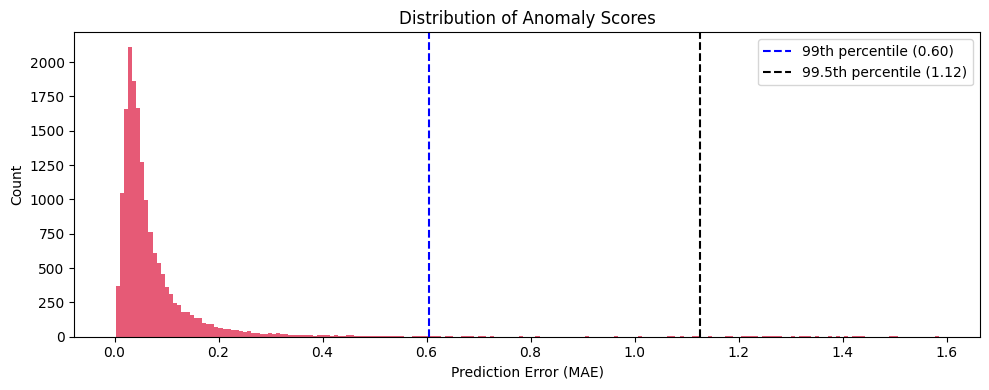

In [22]:
plt.figure(figsize=(10, 4))
plt.hist(errors, bins=200, color="crimson", alpha=0.7)
plt.axvline(np.percentile(errors, 99), color="blue", linestyle="--", label="99th percentile (0.60)")
plt.axvline(np.percentile(errors, 99.5), color="black", linestyle="--", label="99.5th percentile (1.12)")
plt.xlabel("Prediction Error (MAE)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.savefig("error_distribution.png", dpi=150)
plt.show()


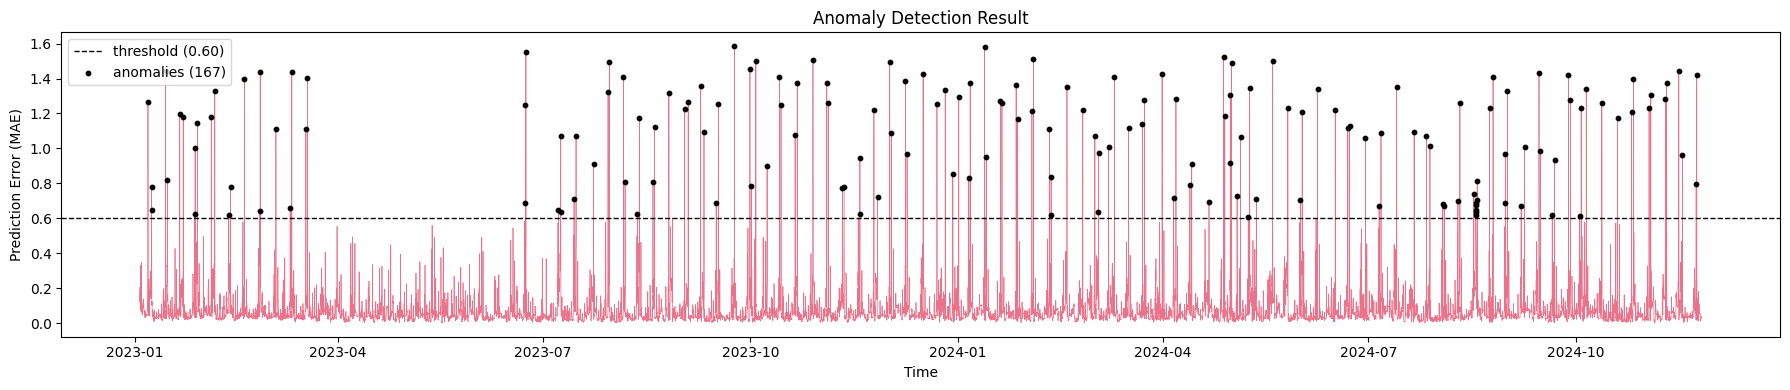

Total anomalies flagged: 167


In [23]:
threshold = np.percentile(errors, 99)
anomalies = errors > threshold
time_index = meta["index"][48:48+len(errors)]

plt.figure(figsize=(18, 4))
plt.plot(time_index, errors, color="crimson", linewidth=0.5, alpha=0.6)
plt.axhline(threshold, color="black", linestyle="--", linewidth=1, label=f"threshold ({threshold:.2f})")
plt.scatter(time_index[anomalies], errors[anomalies], color="black", s=10, zorder=5, label=f"anomalies ({anomalies.sum()})")
plt.title("Anomaly Detection Result")
plt.xlabel("Time")
plt.ylabel("Prediction Error (MAE)")
plt.legend()
plt.tight_layout()
plt.savefig("anomaly_detection_result.png", dpi=150)
plt.show()
print(f"Total anomalies flagged: {anomalies.sum()}")

In [24]:
# find the anomaly indices in October 2023
oct_mask = (time_index >= "2023-10-01") & (time_index <= "2023-10-31")
oct_errors = errors[oct_mask]
oct_times = time_index[oct_mask]
oct_anomalies = oct_errors > threshold

print(f"Anomalies in October 2023: {oct_anomalies.sum()}")
print("Anomaly dates:")
for t, e in zip(oct_times[oct_anomalies], oct_errors[oct_anomalies]):
    print(f"  {t}  →  error: {e:.4f}")


Anomalies in October 2023: 8
Anomaly dates:
  2023-10-01 09:00:00  →  error: 0.7852
  2023-10-03 09:00:00  →  error: 1.4980
  2023-10-08 09:00:00  →  error: 0.8972
  2023-10-13 20:00:00  →  error: 1.4080
  2023-10-14 13:00:00  →  error: 1.2464
  2023-10-20 19:00:00  →  error: 1.0765
  2023-10-21 18:00:00  →  error: 1.3745
  2023-10-28 17:00:00  →  error: 1.5037


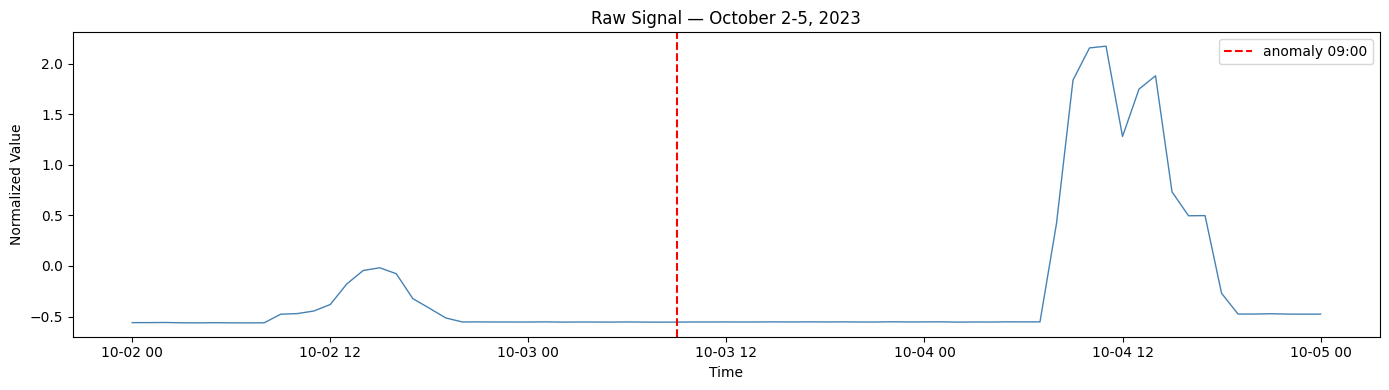

In [27]:
import pandas as pd
mask = (meta["index"] >= "2023-10-02") & (meta["index"] <= "2023-10-05")
zoom_values = meta["values_norm"][mask]
zoom_index = meta["index"][mask]

plt.figure(figsize=(14, 4))
plt.plot(zoom_index, zoom_values, color="steelblue", linewidth=1)
plt.axvline(pd.Timestamp("2023-10-03 09:00"), color="red", linestyle="--", linewidth=1.5, label="anomaly 09:00")
plt.title("Raw Signal — October 2-5, 2023")
plt.xlabel("Time")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()
